In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
df = pd.read_csv("crop_disease_symptom_dataset.csv")
print("Dataset shape:", df.shape)
df.head(10)

Dataset shape: (300, 4)


,Crop,Disease,Symptoms,Solution
0,Sugarcane,Smut,severely infected cane failing to form millabl...,Use hot water treated or disease free setts fo...
1,Rice,Bacterial Blight,milky bacterial ooze visible on cut leaf surface,Use resistant rice varieties; avoid excess nit...
2,Cotton,Root Rot,sudden collapse of healthy looking cotton plants,Improve field drainage to avoid waterlogging; ...
3,Rice,Bacterial Blight,lesions with wavy margins on rice leaf blade,Use resistant rice varieties; avoid excess nit...
4,Cotton,Leaf Curl Virus,leaf margins curling upward giving cupped appe...,Control whitefly vector using Imidacloprid or ...
5,General,Healthy,leaves turgid and green with no curling symptoms,No disease detected. Continue regular field mo...
6,Maize,Rust,yield reduction due to severe rust infection,Apply Mancozeb or Propiconazole fungicide; gro...
7,Sugarcane,Smut,infected buds producing whip instead of normal...,Use hot water treated or disease free setts fo...
8,Wheat,Powdery Mildew,white blister like patches on leaf surface,Apply sulfur based fungicide or Propiconazole ...
9,Maize,Leaf Blight,field showing patches of blighted maize plants,Spray Mancozeb or Carbendazim fungicide at ear...


In [3]:
df["Disease"].value_counts().to_frame(name="Number_of_Symptom_Records")

,Number_of_Symptom_Records
Disease,
Bacterial Blight,29
Smut,28
Root Rot,28
Powdery Mildew,28
Leaf Curl Virus,27
Healthy,27
Rust,27
Red Rot,27
Leaf Rust,27


C:\Users\mansi\AppData\Local\Temp\ipykernel_10320\3373126848.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Disease", order=df["Disease"].value_counts().index, palette="viridis")


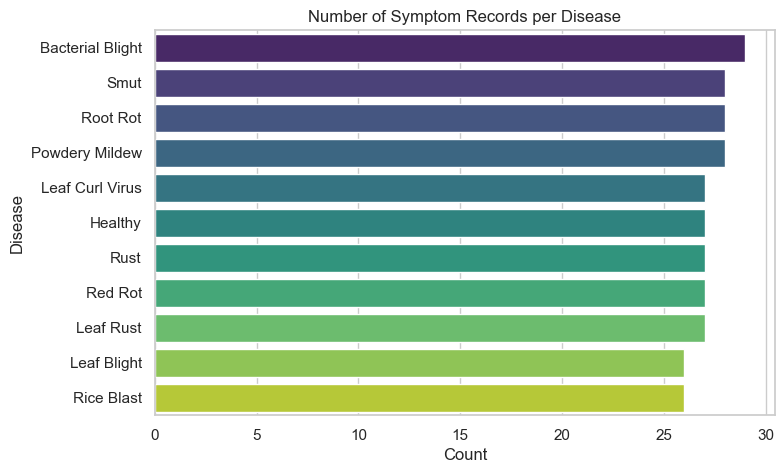

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Disease", order=df["Disease"].value_counts().index, palette="viridis")
plt.title("Number of Symptom Records per Disease")
plt.xlabel("Count")
plt.show()

C:\Users\mansi\AppData\Local\Temp\ipykernel_10320\117772188.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Crop", order=df["Crop"].value_counts().index, palette="mako")


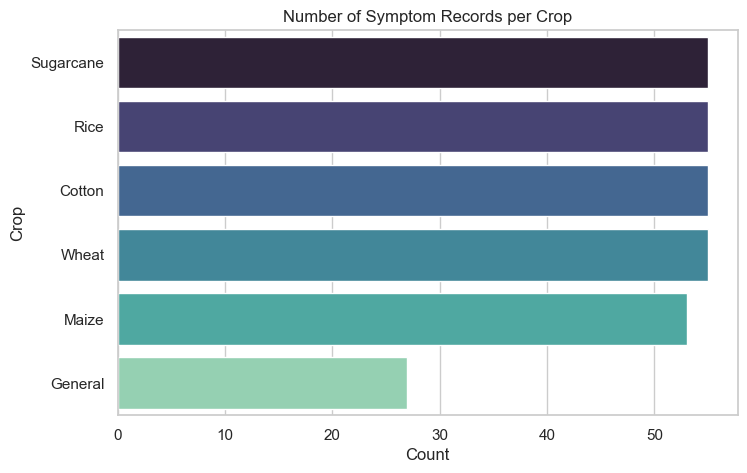

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Crop", order=df["Crop"].value_counts().index, palette="mako")
plt.title("Number of Symptom Records per Crop")
plt.xlabel("Count")
plt.show()

In [7]:
STOPWORDS = set([
    "the", "a", "an", "is", "are", "on", "in", "of", "with", "and", "or",
    "to", "at", "from", "by", "as", "this", "that", "it", "its", "into",
    "such", "than", "then", "there", "have", "has", "had", "showing",
    "visible", "appear", "appears", "observed", "shows", "seen", "like",
    "due", "when", "while", "for", "within", "both", "each"
])

def simple_stem(word):
    """Very small rule based stemmer (suffix stripping) - classic NLP technique."""
    for suffix in ["ing", "edly", "ies", "ed", "es", "s"]:
        if word.endswith(suffix) and len(word) - len(suffix) > 3:
            word = word[: -len(suffix)]
            break
    return word

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)          # cleaning
    tokens = text.split()                            # tokenization
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]  # stopword removal
    tokens = [simple_stem(t) for t in tokens]         # stemming
    return tokens

# Demo of the NLP pipeline on one sentence
sample_sentence = df["Symptoms"].iloc[0]
print("Original :", sample_sentence)
print("Processed:", tokenize(sample_sentence))

Original : severely infected cane failing to form millable stalks
Processed: ['severely', 'infect', 'cane', 'fail', 'form', 'millable', 'stalk']


In [8]:
df["Tokens"] = df["Symptoms"].apply(tokenize)
df[["Symptoms", "Tokens"]].head(5)

,Symptoms,Tokens
0,severely infected cane failing to form millabl...,"[severely, infect, cane, fail, form, millable,..."
1,milky bacterial ooze visible on cut leaf surface,"[milky, bacterial, ooze, cut, leaf, surface]"
2,sudden collapse of healthy looking cotton plants,"[sudden, collapse, healthy, look, cotton, plant]"
3,lesions with wavy margins on rice leaf blade,"[lesion, wavy, margin, rice, leaf, blade]"
4,leaf margins curling upward giving cupped appe...,"[leaf, margin, curl, upward, giving, cupp, app..."


## Step 5: TF-IDF Vectorization (built from scratch using NumPy)

**TF-IDF (Term Frequency - Inverse Document Frequency)** is a core NLP technique
used to convert text into numeric vectors, giving more weight to words that are
frequent in a document but rare across the whole dataset (i.e. more meaningful
disease-specific keywords).

- **TF** (Term Frequency) = how often a word appears in a given symptom record.
- **IDF** (Inverse Document Frequency) = how rare that word is across all 300
  records.
- **TF-IDF = TF x IDF**

This is implemented manually with NumPy (no external ML/NLP library, no model
training) so it stays a pure NLP + AI (information retrieval) technique.

In [9]:
# Build vocabulary from all symptom records
all_tokens = [tok for tokens in df["Tokens"] for tok in tokens]
vocabulary = sorted(set(all_tokens))
vocab_index = {word: i for i, word in enumerate(vocabulary)}

print("Vocabulary size:", len(vocabulary))
print("Sample vocabulary words:", vocabulary[:20])

Vocabulary size: 436
Sample vocabulary words: ['above', 'acros', 'adequate', 'affect', 'after', 'alcoholic', 'along', 'alternate', 'any', 'appear', 'appearance', 'area', 'around', 'arrang', 'bacterial', 'band', 'bark', 'base', 'becom', 'before']


In [10]:
N = len(df)                         # total number of documents (symptom records)
vocab_size = len(vocabulary)

# ---- Term Frequency (TF) matrix ----
tf_matrix = np.zeros((N, vocab_size))
for row_idx, tokens in enumerate(df["Tokens"]):
    counts = Counter(tokens)
    total = len(tokens) if len(tokens) > 0 else 1
    for word, cnt in counts.items():
        tf_matrix[row_idx, vocab_index[word]] = cnt / total

# ---- Inverse Document Frequency (IDF) vector ----
doc_freq = np.count_nonzero(tf_matrix > 0, axis=0)
idf_vector = np.log((N + 1) / (doc_freq + 1)) + 1   # smoothed IDF

# ---- TF-IDF matrix ----
tfidf_matrix = tf_matrix * idf_vector

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (300, 436)


In [12]:
def text_to_tfidf_vector(text):
    tokens = tokenize(text)
    counts = Counter(tokens)
    total = len(tokens) if len(tokens) > 0 else 1
    vec = np.zeros(vocab_size)
    for word, cnt in counts.items():
        if word in vocab_index:
            vec[vocab_index[word]] = (cnt / total) * idf_vector[vocab_index[word]]
    return vec

def cosine_similarity(vec1, vec2):
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return float(np.dot(vec1, vec2) / (norm1 * norm2))

def detect_disease(user_symptoms, top_n=3):
    user_vec = text_to_tfidf_vector(user_symptoms)
    scores = np.array([cosine_similarity(user_vec, tfidf_matrix[i]) for i in range(N)])

    result_df = df.copy()
    result_df["Match_Score"] = scores
    top_matches = result_df.sort_values("Match_Score", ascending=False).head(top_n)
    best = top_matches.iloc[0]

    if best["Match_Score"] == 0:
        return {
            "disease": "Unable to detect",
            "crop": "N/A",
            "confidence": 0.0,
            "solution": "No matching symptoms found in the knowledge base. Please describe symptoms in more detail (e.g. leaf color, spots, growth pattern).",
            "top_matches": top_matches[["Crop", "Disease", "Symptoms", "Match_Score"]]
        }

    return {
        "disease": best["Disease"],
        "crop": best["Crop"],
        "confidence": round(best["Match_Score"] * 100, 2),
        "solution": best["Solution"],
        "top_matches": top_matches[["Crop", "Disease", "Symptoms", "Match_Score"]]
    }

In [13]:
# You can change this text to describe any symptom you observe on the crop
user_input = "leaves have orange powdery spots that rub off when touched"

result = detect_disease(user_input)

print("User described symptoms  :", user_input)
print("-" * 70)
print("Predicted Crop            :", result["crop"])
print("Predicted Disease         :", result["disease"])
print("Confidence (cosine score) :", f'{result["confidence"]}%')
print("Recommended Solution      :", result["solution"])

User described symptoms  : leaves have orange powdery spots that rub off when touched
----------------------------------------------------------------------
Predicted Crop            : Maize
Predicted Disease         : Rust
Confidence (cosine score) : 57.42%
Recommended Solution      : Apply Mancozeb or Propiconazole fungicide; grow rust resistant hybrid seeds; ensure timely sowing to avoid peak humidity period; avoid excess nitrogen application.


In [14]:
# Top matching records (via cosine similarity) used to arrive at the prediction
result["top_matches"]

,Crop,Disease,Symptoms,Match_Score
127,Maize,Rust,powdery reddish spores rubbing off on touch,0.574156
134,Wheat,Leaf Rust,rust colored spores rubbing off on touching le...,0.510912
263,Wheat,Leaf Rust,leaves turning yellow with orange rust spots,0.401561


### Step 8: Interactive Input (type your own symptoms)

In [19]:
# Run this cell and type the symptoms you observe when prompted
user_input = input("Describe the crop symptoms you see: ")

result = detect_disease(user_input)

output_df = pd.DataFrame([[
    user_input, result["crop"], result["disease"],
    f'{result["confidence"]}%', result["solution"]
    
]], columns=["Symptoms_Entered", "Crop", "Predicted_Disease", "Confidence", "Suggested_Solution"])

output_df

Describe the crop symptoms you see:  small white powdery spot on upper surface of leave,yellow leaves with brown spots


,Symptoms_Entered,Crop,Predicted_Disease,Confidence,Suggested_Solution
0,small white powdery spot on upper surface of l...,Wheat,Powdery Mildew,51.17%,Apply sulfur based fungicide or Propiconazole ...


In [20]:
sample_symptoms = [
    "black whip like structure coming out from top of cane",
    "leaves curling upward with thick yellow veins",
    "yellow water soaked streaks on leaf margin drying from tip",
    "reddish discoloration inside stalk with alcoholic smell",
    "plant wilting suddenly with black rotten roots",
    "healthy green leaves with no spots and normal growth",
]

results = []
for symptom in sample_symptoms:
    r = detect_disease(symptom)
    results.append([symptom, r["crop"], r["disease"], f'{r["confidence"]}%', r["solution"]])

test_results_df = pd.DataFrame(results, columns=["Symptoms_Entered", "Crop", "Predicted_Disease",
                                                   "Confidence", "Suggested_Solution"])
test_results_df

,Symptoms_Entered,Crop,Predicted_Disease,Confidence,Suggested_Solution
0,black whip like structure coming out from top ...,Sugarcane,Smut,50.02%,Use hot water treated or disease free setts fo...
1,leaves curling upward with thick yellow veins,Cotton,Leaf Curl Virus,63.32%,Control whitefly vector using Imidacloprid or ...
2,yellow water soaked streaks on leaf margin dry...,Rice,Bacterial Blight,74.42%,Use resistant rice varieties; avoid excess nit...
3,reddish discoloration inside stalk with alcoho...,Sugarcane,Red Rot,52.35%,Use disease free healthy setts for planting; t...
4,plant wilting suddenly with black rotten roots,Cotton,Root Rot,53.7%,Improve field drainage to avoid waterlogging; ...
5,healthy green leaves with no spots and normal ...,General,Healthy,50.49%,No disease detected. Continue regular field mo...


C:\Users\mansi\AppData\Local\Temp\ipykernel_10320\2665011216.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conf_values, y=test_results_df["Predicted_Disease"], palette="crest")


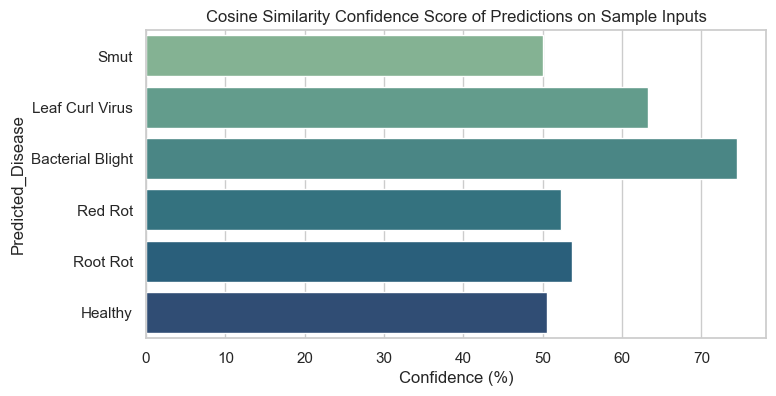

In [17]:
plt.figure(figsize=(8,4))
conf_values = [float(r["Confidence"].strip("%")) for _, r in test_results_df.iterrows()]
sns.barplot(x=conf_values, y=test_results_df["Predicted_Disease"], palette="crest")
plt.title("Cosine Similarity Confidence Score of Predictions on Sample Inputs")
plt.xlabel("Confidence (%)")
plt.show()